In [3]:
sentences = [
    # Cricket
    "The batsman scored a century in the match.",
    "The bowler took three wickets in one over.",
    "The team won the match by chasing a big target.",
    
    # Cooking
    "I love cooking pasta with fresh ingredients.",
    "The chef prepared a delicious three-course meal.",
    "Baking cakes requires precise measurements.",
    
    # Cybersecurity
    "Cybersecurity protects systems from digital attacks.",
    "Strong passwords help prevent unauthorized access.",
    "Encryption ensures data privacy and security.",
    
    # Extra (to make 10)
    "The match was exciting till the last ball."
]

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)

# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Show matrix
print(similarity_matrix)

c:\Users\nakul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nakul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nakul\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to ru

[[ 1.0000002   0.5799761   0.42358023 -0.10057908  0.12073506  0.09554447
  -0.00584987 -0.04475228 -0.00762772  0.3771995 ]
 [ 0.5799761   1.0000001   0.39083737  0.00143573  0.3558568   0.06341826
  -0.01357421 -0.01510067  0.01472597  0.3718483 ]
 [ 0.42358023  0.39083737  0.9999999  -0.08308174 -0.00955279 -0.00445325
   0.06205705 -0.01858022  0.00771224  0.5036243 ]
 [-0.10057908  0.00143573 -0.08308174  1.0000001   0.2659997   0.10616048
   0.00794861  0.02881315  0.09302725  0.03177557]
 [ 0.12073506  0.3558568  -0.00955279  0.2659997   0.99999994  0.20211539
  -0.06642335 -0.06724439 -0.02260282  0.03693975]
 [ 0.09554447  0.06341826 -0.00445325  0.10616048  0.20211539  1.
   0.00386286 -0.00959918  0.08727887 -0.05301059]
 [-0.00584987 -0.01357421  0.06205705  0.00794861 -0.06642335  0.00386286
   1.0000001   0.38274974  0.44287    -0.03459389]
 [-0.04475228 -0.01510067 -0.01858022  0.02881315 -0.06724439 -0.00959918
   0.38274974  1.0000001   0.36570114 -0.07674415]
 [-0.007

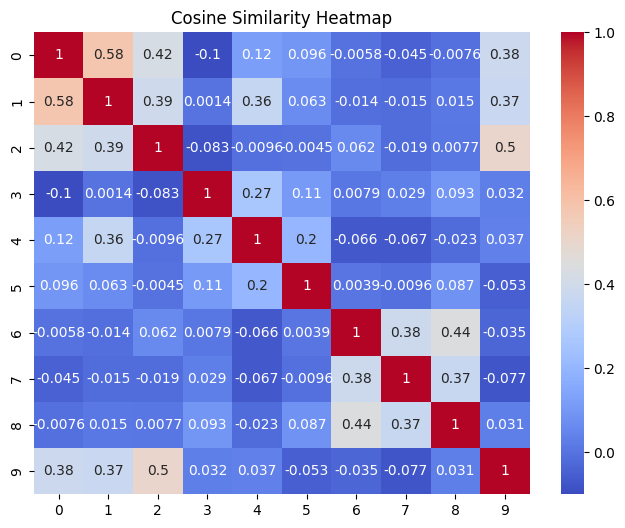

In [5]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Heatmap")
plt.show()

In [6]:
# Query sentence
query = "The bowler took three wickets in one over"

# Encode query
query_embedding = model.encode([query])

# Compute similarity with all sentences
scores = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = scores.argsort()[-2:][::-1]

print("Top 2 similar sentences:\n")
for idx in top_indices:
    print(sentences[idx], "-> Score:", scores[idx])

Top 2 similar sentences:

The bowler took three wickets in one over. -> Score: 0.99136364
The batsman scored a century in the match. -> Score: 0.5611449
